# GEEZ OCR

Ge'ez an ancient South Semitic language that originated in the Horn of Africa, specifically northern Ethiopia and southern Eritrea. It is the historical root or primary influence for modern Horn of African languages like Amharic, Tigrinya, and Tigré. t preserves centuries of invaluable historical chronicles, philosophical works, traditional medicine, and unique religious texts (including the Ge'ez Bible). It contain around 287 characters featuring 34 core base consonants, with each expanding into 7 vowel forms (orders) and irregular characters.

This project is going to use [Yaredoffice/geez-characters](https://huggingface.co/datasets/Yaredoffice/geez-characters) dataset to train an OCR model. The dataset was downloaded to the project in order to preprocess it and handle class label inference. 

## Import the necessary libraries and utility functions

In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from utils import *
from models.ann_models import *
from models.cnn_models import *

## 1. Load and Explore the Dataset

### 1.1. Load the data

In [2]:
(X_train, y_train, train_paths), (X_test, y_test, test_paths)  = load_data("dataset")

Found 13776 files belonging to 287 classes.
Found 1435 files belonging to 287 classes.


### 1.2. Explore the data

In [3]:
print(f"X_train.shape  = {X_train.shape}")
print(f"Y_train.shape = {y_train.shape}")
print(f"X_test.shape  = {X_test.shape}")
print(f"Y_test.shape = {y_test.shape}")

print(f"X_train[0] is: \n{X_train[0]}\n")
print(f"X_train[-1] is: \n{X_train[-1]}\n")
print(f"Y_train[0] is: \n{y_train[0]}\n")
print(f"Y_train[-1] is: \n{y_train[-1]}\n")

X_train.shape  = (13776, 32, 32, 1)
Y_train.shape = (13776,)
X_test.shape  = (1435, 32, 32, 1)
Y_test.shape = (1435,)
X_train[0] is: 
[[[237.     ]
  [249.09375]
  [255.     ]
  ...
  [254.45312]
  [254.32812]
  [255.     ]]

 [[237.67188]
  [249.31421]
  [255.     ]
  ...
  [254.45312]
  [254.10767]
  [254.32812]]

 [[237.54688]
  [249.2732 ]
  [254.38403]
  ...
  [253.34155]
  [253.39111]
  [254.     ]]

 ...

 [[238.34375]
  [249.53467]
  [254.29907]
  ...
  [251.5647 ]
  [252.8584 ]
  [255.     ]]

 [[229.04688]
  [246.26367]
  [253.31958]
  ...
  [250.02368]
  [251.75342]
  [254.67188]]

 [[223.     ]
  [243.82812]
  [251.73438]
  ...
  [251.     ]
  [251.98438]
  [254.     ]]]

X_train[-1] is: 
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [

## 1.3. Show randomly selected images
Show randomly selected 20 images from both the training and test datasets with their actual labels to see what the images and characters look like.

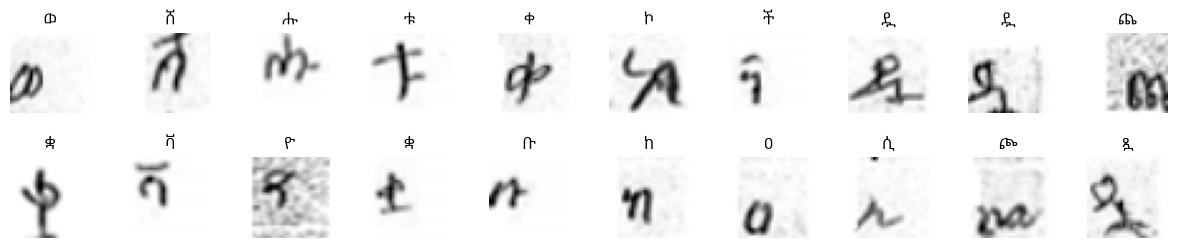

In [4]:
# From the training dataset
show_images(X_train, y_train, num_of_images=20)

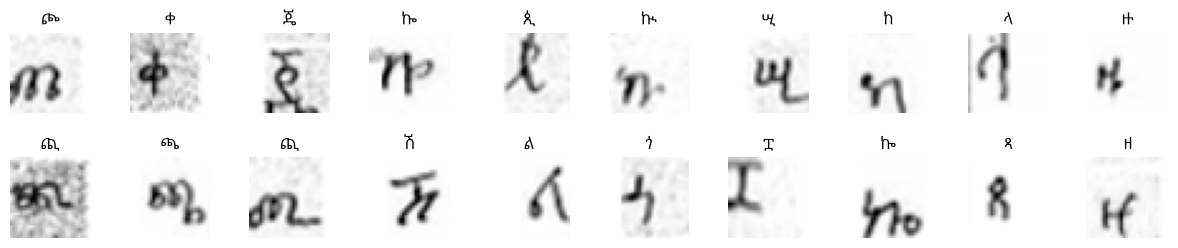

In [5]:
# From the test dataset
show_images(X_test, y_test, num_of_images=20)

## 2. Train and Fine-tune the Selected Models
Since the project is trying out different Artificial Neural Networks and Convolutional Neural Networks to identify Ge'ez characters, we are going to cross validate the models using `Stratified Folds` to test how well the models generalize to new unseen data. 

## 2.1. Overview of the Selected Model

In [31]:
regularized_deeper_cnn = build_regularized_deeper_cnn()
regularized_deeper_cnn.summary()

Model: "Regularized_Deeper_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation_34 (RandomRotation)  │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_34 (RandomZoom)          │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation_34                │ (None, 32, 32, 1)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_34 (Rescaling)             │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_241 (Conv2D)                  │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_241              │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_241 (Activation)          │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_242 (Conv2D)                  │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_242              │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_242 (Activation)          │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_102 (MaxPooling2D)     │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d_102                │ (None, 16, 16, 64)          │               0 │
│ (SpatialDropout2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_243 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_243              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_243 (Activation)          │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_244 (Conv2D)                  │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_244              │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_244 (Activation)          │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 517,663 (1.97 MB)

 Trainable params: 516,447 (1.97 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 2.2 Further Train the Model using K-fold

I am going to use `Early Stopping` to stop training automatically as soon as validation loss stops improving.

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    min_delta=1e-3,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

In [30]:
print("=" * 50)
print("Deeper CNN Model")
print("=" * 50)
regularized_deeper_cnn_results = cross_validate_model(
    build_regularized_deeper_cnn,
    X_train,
    y_train,
    epochs=150,
    callback=[early_stopping, reduce_lr]
)

Deeper CNN Model

 ===================== Fold 1 =====================
Epoch 1/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 160ms/step - accuracy: 0.0032 - loss: 7.1026 - top5_accuracy: 0.0176 - val_accuracy: 0.0062 - val_loss: 6.9879 - val_top5_accuracy: 0.0232 - learning_rate: 2.5000e-04
Epoch 2/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.0053 - loss: 6.8986 - top5_accuracy: 0.0251 - val_accuracy: 0.0022 - val_loss: 6.8342 - val_top5_accuracy: 0.0200 - learning_rate: 2.5000e-04
Epoch 3/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.0100 - loss: 6.5985 - top5_accuracy: 0.0393 - val_accuracy: 0.0080 - val_loss: 6.6739 - val_top5_accuracy: 0.0327 - learning_rate: 2.5000e-04
Epoch 4/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.0133 - loss: 6.1513 - top5_accuracy: 0.0610 - val_accuracy: 0.0218 - val_loss: 5.9716 - val_top5_accuracy: 0.0762 - learning_rate: 2.5000e-04
Epoch 5/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.0220 - loss:

In [32]:
model_results = {}

# Mean of the results of the 5 fold trainings  of the model
summarized_results = summarize_results(regularized_deeper_cnn_results)
print(f"Mean Train Accuracy: {summarized_results["mean_train_accuracy"]}")
print(f"Mean Cross-Validation Accuracy: {summarized_results["mean_cv_accuracy"]}")
print(f"STD of Training Accuracy: {summarized_results["std_train_accuracy"]}")
print(f"STD of Cross-Validation Accuracy: {summarized_results["std_cv_accuracy"]}")
print(f"Mean Gap: {summarized_results["mean_gap"]}")
print(f"Mean Train Top 5 Accuracy: {summarized_results["mean_train_top5_accuracy"]}")
print(f"Mean Cross-Validation Top 5 Accuracy: {summarized_results["mean_cv_top5_accuracy"]}")

# Add the results to the ann results
model_results = summarized_results

Mean Train Accuracy: 0.8767603874206543
Mean Cross-Validation Accuracy: 0.8115557670593262
STD of Training Accuracy: 0.021848109799379647
STD of Cross-Validation Accuracy: 0.018889059022114095
Mean Gap: 0.06520462036132812
Mean Train Top 5 Accuracy: 0.9906903505325317
Mean Cross-Validation Top 5 Accuracy: 0.969294548034668
